1.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

2.

In [3]:
delivery_df = pd.read_csv('delivery_time.csv')

3.

<Axes: xlabel='weather', ylabel='delivery_time_min'>

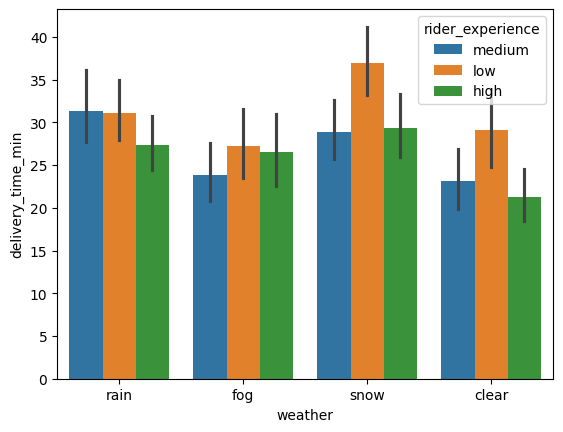

In [4]:
sns.barplot(data=delivery_df, x='weather', y='delivery_time_min', hue='rider_experience')

In [ ]:
답03 = '1'

4.

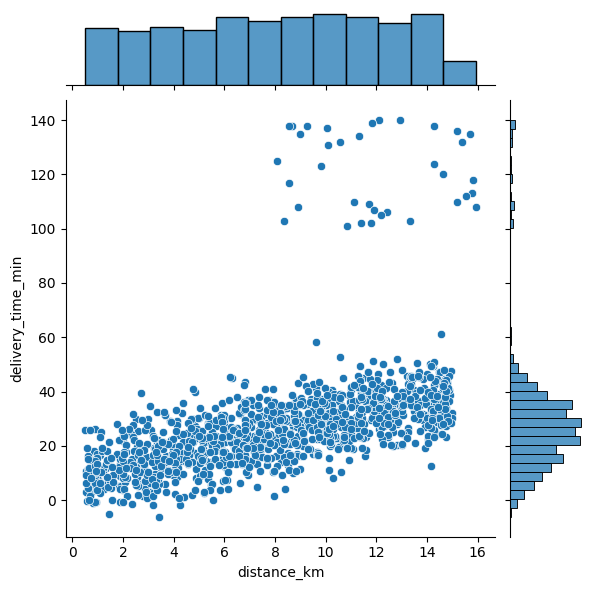

In [5]:
sns.jointplot(data=delivery_df, x='distance_km', y='delivery_time_min')

In [6]:
del_df = delivery_df.drop(delivery_df[delivery_df['delivery_time_min'] >= 100].index, axis=0)

5.

In [7]:
del_df.drop(del_df[del_df['delivery_time_min'] < 0].index, axis=0, inplace=True)
del_df.reset_index(drop=True, inplace=True)

6.

In [8]:
del_df.drop(columns=['order_amount', 'num_items'], axis=1, inplace=True)

7.

In [9]:
cat_col = ['rider_experience', 'weather', 'order_time']

In [10]:
encoding_df = pd.get_dummies(data=del_df, columns=cat_col, drop_first=True)

8.

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [12]:
encoding_df['promotion_applied'] = le.fit_transform(encoding_df['promotion_applied'])

9.

In [13]:
from sklearn.model_selection import train_test_split

X = encoding_df.drop(columns=['delivery_time_min'])
y = encoding_df['delivery_time_min']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

10.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

11.

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

12.

In [16]:
from sklearn.ensemble import RandomForestRegressor

In [17]:
rfr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

13.

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization

tf.random.set_seed(42)

In [22]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

model.fit(X_train, y_train, epochs=50, batch_size=128, validation_data=(X_test, y_valid))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 765.3699 - mean_absolute_error: 25.2824 - val_loss: 758.8604 - val_mean_absolute_error: 25.1861
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 736.5548 - mean_absolute_error: 24.7981 - val_loss: 751.4257 - val_mean_absolute_error: 25.0590
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 711.7830 - mean_absolute_error: 24.3586 - val_loss: 743.5265 - val_mean_absolute_error: 24.9225
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 689.4349 - mean_absolute_error: 23.9479 - val_loss: 734.7917 - val_mean_absolute_error: 24.7705
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 668.1324 - mean_absolute_error: 23.5488 - val_loss: 724.6851 - val_mean_absolute_error: 24.5945
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 646.6334 - mean_absolute_error: 23.1406 - val_loss: 712.8623 - val_mean_absolute_error: 24.3896
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 624.5357 - mean_absolute_error: 22.7

14.

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [24]:
es = EarlyStopping(monitor='val_loss', patience=5)
mc = ModelCheckpoint(monitor='val_loss', save_best_only=True, filepath='best_model.h5')
callbacks = [es, mc]

model.fit(X_train, y_train, epochs=50, batch_size=128, validation_data=(X_test, y_valid), callbacks=callbacks)

Epoch 1/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 40.5446 - mean_absolute_error: 5.2803

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 42.5652 - mean_absolute_error: 5.1769 - val_loss: 74.4794 - val_mean_absolute_error: 6.7505
Epoch 2/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 40.2105 - mean_absolute_error: 5.2667

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 42.1579 - mean_absolute_error: 5.1541 - val_loss: 74.1181 - val_mean_absolute_error: 6.7386
Epoch 3/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 40.0135 - mean_absolute_error: 5.2598

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 41.7963 - mean_absolute_error: 5.1348 - val_loss: 73.7799 - val_mean_absolute_error: 6.7279
Epoch 4/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 39.7833 - mean_absolute_error: 5.2479

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 41.4572 - mean_absolute_error: 5.1177 - val_loss: 73.5107 - val_mean_absolute_error: 6.7203
Epoch 5/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - loss: 39.5606 - mean_absolute_error: 5.2352

...

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 33.4926 - mean_absolute_error: 4.5893 - val_loss: 67.8013 - val_mean_absolute_error: 6.5562
Epoch 46/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 35.4499 - mean_absolute_error: 4.9931

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 33.3778 - mean_absolute_error: 4.5811 - val_loss: 67.7745 - val_mean_absolute_error: 6.5578
Epoch 47/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 35.3136 - mean_absolute_error: 4.9801

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 33.2489 - mean_absolute_error: 4.5715 - val_loss: 67.7322 - val_mean_absolute_error: 6.5566
Epoch 48/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 33.1229 - mean_absolute_error: 4.5612 - val_loss: 67.7576 - val_mean_absolute_error: 6.5597
Epoch 49/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 35.1937 - mean_absolute_error: 4.9717

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 33.0290 - mean_absolute_error: 4.5538 - val_loss: 67.6068 - val_mean_absolute_error: 6.5553
Epoch 50/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 35.0883 - mean_absolute_error: 4.9668

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 32.9027 - mean_absolute_error: 4.5464 - val_loss: 67.5112 - val_mean_absolute_error: 6.5474
